In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# 1) Load dataset (replace with your CSV file)
df = pd.read_csv("Cryptocurrencies_to_USD_default_day_2021-01-09.csv")  # must contain a 'price' column

df.head()

,datetime,low,high,open,close,volumefrom,volumeto,cryptocurrency,image_url,coin_name
0,2019-12-06,7323.86,7607.79,7406.75,7558.58,28169.83,2.098513e+08,BTC,https://www.cryptocompare.com/media/19633/btc.png,Bitcoin
1,2019-12-07,7503.10,7640.51,7558.58,7514.86,14093.87,1.065722e+08,BTC,https://www.cryptocompare.com/media/19633/btc.png,Bitcoin
2,2019-12-08,7414.51,7594.80,7514.86,7539.70,15949.09,1.200003e+08,BTC,https://www.cryptocompare.com/media/19633/btc.png,Bitcoin
3,2019-12-09,7296.42,7667.04,7539.70,7350.62,35089.72,2.621613e+08,BTC,https://www.cryptocompare.com/media/19633/btc.png,Bitcoin
4,2019-12-10,7176.42,7403.64,7350.62,7233.84,23348.59,1.704194e+08,BTC,https://www.cryptocompare.com/media/19633/btc.png,Bitcoin


In [14]:
# Remove unwanted features
df.drop(columns=['datetime', 'cryptocurrency', 'image_url', 'coin_name'], inplace=True)

In [8]:
# To see the statistical parameters
df.describe()

,low,high,open,close,volumefrom,volumeto
count,40100.000000,40100.000000,40100.000000,40100.000000,4.010000e+04,4.010000e+04
mean,314.118283,345.155452,325.662223,327.938645,1.926498e+07,1.625537e+07
std,2141.570521,2451.924949,2235.218938,2259.217331,1.130234e+08,1.002620e+08
min,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00
25%,0.025938,0.028100,0.026840,0.026898,5.679118e+04,3.266953e+04
50%,0.320300,0.362500,0.339000,0.340550,5.767831e+05,4.556330e+05
75%,3.444250,3.806000,3.608250,3.618250,4.348087e+06,3.642490e+06
max,40526.520000,109332.600000,43265.170000,43265.170000,1.097729e+10,4.753170e+09


In [9]:
# To see the datatypes and info of the dataset
print(df.info())
print(df.dtypes)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40100 entries, 0 to 40099
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    40100 non-null  object 
 1   low         40100 non-null  float64
 2   high        40100 non-null  float64
 3   open        40100 non-null  float64
 4   close       40100 non-null  float64
 5   volumefrom  40100 non-null  float64
 6   volumeto    40100 non-null  float64
dtypes: float64(6), object(1)
memory usage: 2.1+ MB
None
datetime       object
low           float64
high          float64
open          float64
close         float64
volumefrom    float64
volumeto      float64
dtype: object


In [10]:
# Check the null values from the dataset
df.isnull().sum()

datetime      0
low           0
high          0
open          0
close         0
volumefrom    0
volumeto      0
dtype: int64

In [15]:
# Convert the object feature into the float
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].str.replace(',', '', regex=True) # Remove the commas
        df[col] = df[col].replace('-', np.nan) # Replace '-' with np.nan
        df[col] = df[col].astype("float64")

In [16]:
# Encode the categorical values
import pickle
encoders = {}

for col in df.columns:
    if df[col].dtype == 'object':
        encoder = LabelEncoder()
        df[col]= encoder.fit_transform(df[col])
        encoders[col] = encoder

with open('ridge_encoders.pkl', 'wb') as f:
    pickle.dump(encoders, f)

print("Encoders dumped successfully!")

Encoders dumped successfully!


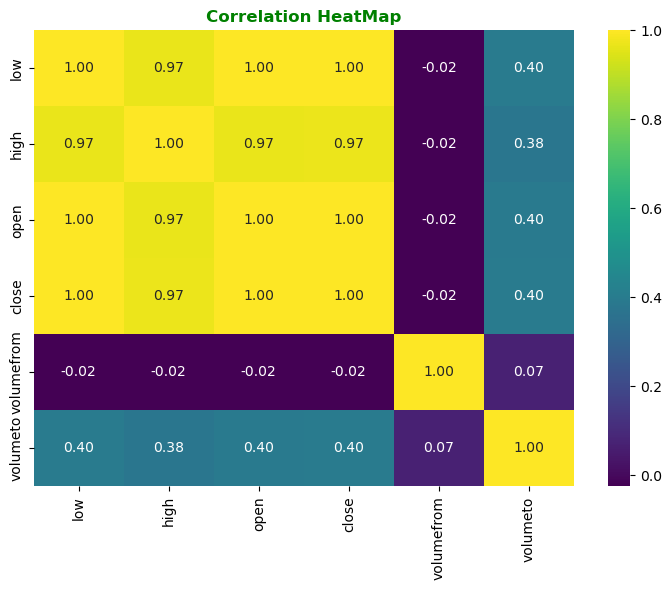

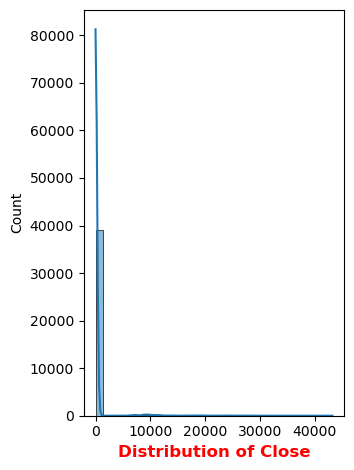

In [18]:
# Basic data visulizations
plt.figure(figsize=(14,6))

# Correlation map
plt.subplot(1,2,1)
sns.heatmap(df.corr(), annot=True, cmap='viridis', fmt='.2f')
plt.title("Correlation HeatMap", color='green', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Distribution Table of Close
plt.subplot(1,2,2)
sns.histplot(df['close'], kde=True, bins=30)
plt.xlabel("Distribution of Close", color='red', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [19]:
df = df.dropna()

# Extract the independent and dependent features 
X = df.drop(columns=['close'])
y = df['close']

# Split the dataset into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the dataset(Standardization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [20]:
# Model + Hyperparameter Tuning
ridge_model = Ridge()

param_grid = {'alpha': [0.001, 0.01, 0.1, 1, 10]}
grid = GridSearchCV(
    ridge_model, 
    param_grid,
    scoring='r2',
    cv=5,
    n_jobs=-1,
    verbose=1
)
grid.fit(X_train_scaled, y_train)

# Find out the best grid
best_grid = grid.best_estimator_

# Predict the model
y_pred = best_grid.predict(X_test_scaled)

Fitting 5 folds for each of 5 candidates, totalling 25 fits


In [21]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error : ", round(mse, 2))
print("Mean Absolute Error : ", round(mae, 2))
print("Recall Score : ", round(r2, 2))

Mean Squared Error :  22325.34
Mean Absolute Error :  15.01
Recall Score :  1.0


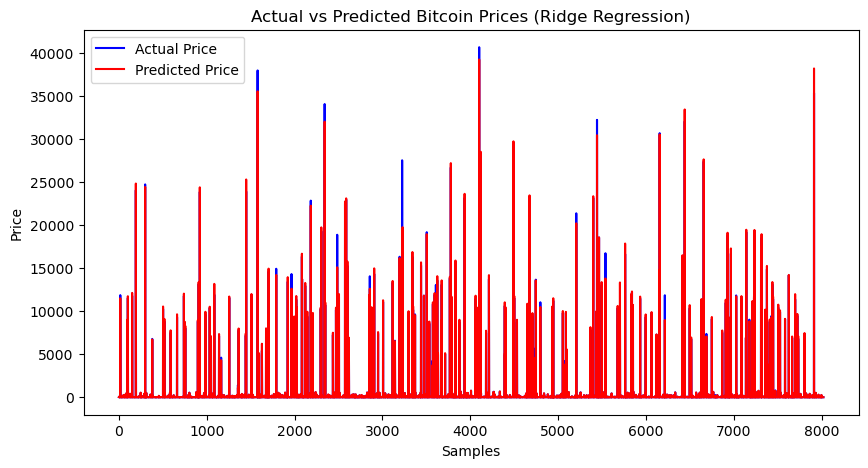

In [22]:
# Plot for the actual vs predicted

plt.figure(figsize=(10, 5))
plt.plot(y_test.values, label='Actual Price', color='blue')
plt.plot(y_pred, label='Predicted Price', color='red')
plt.title('Actual vs Predicted Bitcoin Prices (Ridge Regression)')
plt.xlabel('Samples')
plt.ylabel('Price')
plt.legend()
plt.show()

In [26]:
import joblib
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# Create the pipeline
pipe = make_pipeline(StandardScaler(), best_grid)
pipe.fit(X_train, y_train)

# Save the trained pipeline
joblib.dump(pipe, "saved_models/ridge_pipeline.pkl")

print("Model saved successfully!")

Model saved successfully!


In [28]:
new_data = {
    "datetime": ["2019-12-06", "2019-12-07", "2019-12-08", "2019-12-09", "2019-12-10"],
    "low": [7323.86, 7503.10, 7414.51, 7296.42, 7176.42],
    "high": [7607.79, 7640.51, 7594.80, 7667.04, 7403.64],
    "open": [7406.75, 7558.58, 7514.86, 7539.70, 7350.62],
    "close": [7558.58, 7514.86, 7539.70, 7350.62, 7233.84],
    "volumefrom": [28169.83, 14093.87, 15949.09, 35089.72, 23348.59],
    "volumeto": [2.098513e+08, 1.065722e+08, 1.200003e+08, 2.621613e+08, 1.704194e+08]
}

df = pd.DataFrame(new_data)

pipe = joblib.load("saved_models/ridge_pipeline.pkl")
y_pred = pipe.predict(df)
print("Predicted Bitcoin Price : ", y_pred)

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- close
- datetime
